<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/missions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Astrophysical Data Sources**

Code pipeline to query **IRSA** (Infrared, Near-Infrared), **HEASARC** (Ultraviolet, X-Ray, Gamma Ray)

*Author: Alexander Del Toro Barba, PhD*

In [ ]:
!pip install astropy astroquery matplotlib numpy requests -q

#### **Define astronomical object and get skycoordinates**

*First choose an astronomical object (e.g. galaxy, nebula, star) and query its coordinates*

In [2]:
# Define object
object_name = 'M31'
# Alternatives: 'Abell 2125'

In [62]:
# Get and set skycoordinates of object
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord

skyobject = Simbad.query_object(object_name)
ra_hms = skyobject['RA'][0]
dec_dms = skyobject['DEC'][0]
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
print(skyobject)
print("\nCoordinates:")
print("RA (h:m:s):", ra_hms)
print("DEC (d:m:s):", dec_dms)

MAIN_ID      RA          DEC      RA_PREC ... COO_WAVELENGTH     COO_BIBCODE     SCRIPT_NUMBER_ID
          "h:m:s"      "d:m:s"            ...                                                    
------- ------------ ------------ ------- ... -------------- ------------------- ----------------
  M  31 00 42 44.330 +41 16 07.50       7 ...              I 2006AJ....131.1163S                1

Coordinates:
RA (h:m:s): 00 42 44.330
DEC (d:m:s): +41 16 07.50


In [32]:
# Convert from Right Ascension (RA) and Declination (DEC) to decimal degree
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
ra_deg = coord.ra.deg # round(coord.ra.deg, 2)
dec_deg = coord.dec.deg # round(coord.dec.deg, 2)

print("RA in degrees:", ra_deg)
print("DEC in degrees:", dec_deg)

RA in degrees: 10.684708333333331
DEC in degrees: 41.26875


In [33]:
# Convert from decimal degree to Right Ascension (RA) and Declination (DEC)
coord = SkyCoord(ra=ra_deg, dec=dec_deg, unit='deg', frame='icrs')

# RA: hours, minutes, seconds. DEC: degrees, arcminutes, arcseconds
ra_hms = coord.ra.to_string(unit='hour', sep=' ', precision=3, pad=True)
dec_dms = coord.dec.to_string(unit='deg', sep=' ', precision=2, alwayssign=True, pad=True)

print("RA (h:m:s):", ra_hms)
print("DEC (d:m:s):", dec_dms)

RA (h:m:s): 00 42 44.330
DEC (d:m:s): +41 16 07.50


In [34]:
# Reverse check to see to which object the coordinates belong
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
result = Simbad.query_region(coord, radius='0d0m5s')  # Search within a small radius (5 arcseconds)
if result:
    print(result['MAIN_ID'][0])  # Show the main name of the object
else:
    print("No object found in SIMBAD at these coordinates.")
object_name = 'MAIN_ID'

M  31


#### **HEASARC (X-Ray, Gamma Ray)**

HEASARC (High Energy Astrophysics Science Archive Research Center): data from missions observing the high-energy universe, like X-rays and gamma rays. Like black holes, supernovas, and active galaxies
* Missions: Chandra, XMM-Newton, Swift, Fermi, NuSTAR
* Website: heasarc.gsfc.nasa.gov

In [5]:
# Query all available missions from library
from astroquery.heasarc import Heasarc
heasarc = Heasarc()
missions = heasarc.query_mission_list()
print(missions)

 Mission     Table                                  Table Description                               
---------- ---------- ------------------------------------------------------------------------------
     AGILE   agilecat                       First AGILE Catalog of High-Confidence Gamma-Ray Sources
     AGILE agileupvar              Updated AGILE Catalog of Bright Gamma-Ray Sources and Variability
     AKARI   akaribsc                      AKARI/FIS All-Sky Survey Bright Source Catalog, Version 1
     AKARI   akaripsc                       AKARI/IRC All-Sky Survey Point Source Catalog, Version 1
       ANS ansuvpscat                            ANS Ultraviolet Photometry Catalog of Point Sources
   ARIEL V    ariel3a                                                        3rd Ariel-V SSI Catalog
   ARIEL V     ariel5                                                        Ariel V All-Sky Monitor
      ASCA ascaegclus                           ASCA Elliptical Galaxies and Galaxy Cluster

In [6]:
# Select mission
mission='chanmaster'

Main X-ray missions:
- `chanmaster`: Chandra Master Catalog
- `csc2master`: Chandra Source Catalog 2.0
- `xmmmaster`: XMM-Newton Master Catalog
- `xmmssc`: XMM-Newton Serendipitous Source Catalog
- `swiftmastr`: Swift Master Catalog
- `swiftxrtspec`: Swift-XRT Spectral Database
- `rass2rxs`: ROSAT All-Sky Survey Catalogs
- `exomaster`: EXOSAT Master Catalog
- `numaster`: NuSTAR Master Catalog

For other wavelengths/multi-wavelength:
- `fermimastr`: Fermi Master Catalog (gamma-ray)
- `intmaster`: INTEGRAL Master Catalog (gamma-ray)
- `suzamaster`: Suzaku Master Catalog
- `hstadvize`: Hubble Space Telescope Pointed Observations (optical)
- `jwstmaster`: James Webb Space Telescope Master Catalog (infrared)

In [7]:
# Query observations from one mission (PI - Principal Investigator. Lead scientist for observation)
chanmaster_data = heasarc.query_object('*', mission)
print(chanmaster_data)

OBSID        STATUS        ...                    PI                    PUBLIC_DATE
                           ...                                              mjd    
----- -------------------- ... ---------------------------------------- -----------
 6616 archived             ... Miller                                         54159
 7587 archived             ... Canizares                                      54502
28092 untriggered          ... Canizares                                          0
29852 untriggered          ... Canizares                                          0
28354 unobserved           ... Kargaltsev                                         0
30481 untriggered          ... Canizares                                          0
28775 untriggered          ... Canizares                                          0
13814 archived             ... Kuntz                                          56576
13842 archived             ... Baganoff                                     

In [8]:
# Query a specific object in mission
object_data = heasarc.query_object(object_name, mission='chanmaster')
print(object_data)

OBSID        STATUS        ... PUBLIC_DATE SEARCH_OFFSET_
                           ...     mjd                   
----- -------------------- ... ----------- --------------
15562 archived             ...       56965  1.017 (M31)\n
15273 archived             ...       56948  1.000 (M31)\n
15275 archived             ...       56965  1.017 (M31)\n
15277 archived             ...       56945  0.953 (M31)\n
15274 archived             ...       56948  1.000 (M31)\n
15276 archived             ...       56965  1.017 (M31)\n
15278 archived             ...       56945  0.953 (M31)\n
15561 archived             ...       56948  1.000 (M31)\n
15563 archived             ...       56945  0.953 (M31)\n
  ...                  ... ...         ...            ...
  273 archived             ...       52095  0.019 (M31)\n
  278 archived             ...       52242  0.019 (M31)\n
 2904 archived             ...       52604  0.019 (M31)\n
 1570 archived             ...       52464  0.019 (M31)\n
 1569 archived

In [9]:
# Reduce to specific columns for object
specific_data = heasarc.query_object(object_name, mission='chanmaster', fields='OBSID,ra,dec,exposure')
print(specific_data)

OBSID    RA      DEC    EXPOSURE SEARCH_OFFSET_
        deg      deg       s                   
----- -------- -------- -------- --------------
15562 10.70250 41.25833    77130  1.017 (M31)\n
15273 10.68458 41.28542    77060  1.000 (M31)\n
15275 10.70250 41.25833    77060  1.017 (M31)\n
15277 10.66875 41.25833    74770  0.953 (M31)\n
15274 10.68458 41.28542    73560  1.000 (M31)\n
15276 10.70250 41.25833    73500  1.017 (M31)\n
15278 10.66875 41.25833    72740  0.953 (M31)\n
15561 10.68458 41.28542    70560  1.000 (M31)\n
15563 10.66875 41.25833    69900  0.953 (M31)\n
  ...      ...      ...      ...            ...
  273 10.68500 41.26897     1200  0.019 (M31)\n
  278 10.68500 41.26897     1190  0.019 (M31)\n
 2904 10.68500 41.26897     1190  0.019 (M31)\n
 1570 10.68500 41.26897     1190  0.019 (M31)\n
 1569 10.68500 41.26897     1190  0.019 (M31)\n
  277 10.68500 41.26897     1190  0.019 (M31)\n
  276 10.68500 41.26897     1190  0.019 (M31)\n
  275 10.68500 41.26897     1190  0.019 

In [10]:
# Initialize the Heasarc class
heasarc = Heasarc()

# Coordinates for galaxy
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
# coord = SkyCoord(ra="15h41m14.8s", dec="+66d16m03s", unit=('hourangle', 'deg'), frame='icrs')

# Query Chandra data
# Using 'chanmaster' for the Chandra Master Catalog
chandra_result = heasarc.query_region(
    coord,
    mission='chanmaster',
    radius='0.2 deg'  # Increased radius to ensure we catch all relevant observations
)

# Print the result
if chandra_result is not None and len(chandra_result) > 0:
    print(f"Found {len(chandra_result)} Chandra observations")
    for obs in chandra_result:
        print(f"\nObservation ID: {obs['OBSID']}")
        print(f"Exposure Time: {obs['EXPOSURE']} seconds")
else:
    print("No Chandra observations found")

Found 212 Chandra observations

Observation ID: 15562
Exposure Time: 77130.0 seconds

Observation ID: 15275
Exposure Time: 77060.0 seconds

Observation ID: 15273
Exposure Time: 77060.0 seconds

Observation ID: 15277
Exposure Time: 74770.0 seconds

Observation ID: 15274
Exposure Time: 73560.0 seconds

Observation ID: 15276
Exposure Time: 73500.0 seconds

Observation ID: 15278
Exposure Time: 72740.0 seconds

Observation ID: 15561
Exposure Time: 70560.0 seconds

Observation ID: 15563
Exposure Time: 69900.0 seconds

Observation ID: 11252
Exposure Time: 58870.0 seconds

Observation ID: 14196
Exposure Time: 53830.0 seconds

Observation ID: 13827
Exposure Time: 51880.0 seconds

Observation ID: 13825
Exposure Time: 49980.0 seconds

Observation ID: 13828
Exposure Time: 49880.0 seconds

Observation ID: 14198
Exposure Time: 49870.0 seconds

Observation ID: 1912
Exposure Time: 46970.0 seconds

Observation ID: 14197
Exposure Time: 46850.0 seconds

Observation ID: 5925
Exposure Time: 46680.0 seconds

#### **IRSA**

IRSA (Infrared Science Archive): This archive focuses on infrared data, which reveals cooler objects in space, like dust clouds where stars are born, distant galaxies, and planets in our solar system
* Spitzer, WISE, Herschel, SOFIA
* Website: irsa.ipac.caltech.edu

The **IRSA Catalog** refers to the astronomical data and resources provided by the **Infrared Science Archive (IRSA)**. IRSA is an essential facility hosted by NASA, tasked with curating and distributing infrared astronomical data collected from missions and projects. It enables astronomers to search for and access large-scale datasets related to infrared observations of celestial objects.

1. **Infrared Data**: IRSA focuses on data in the infrared spectrum, which allows astronomers to study phenomena such as:
   - Star formation.
   - Interstellar dust and gas.
   - Galaxy formation and evolution.
   - Objects obscured in visible light by dust.

2. **Access to Multiple Missions**: IRSA provides access to data from several missions, such as:
   - **Spitzer Space Telescope** (e.g., GLIMPSE, SEIP catalogs).
   - **WISE (Wide-field Infrared Survey Explorer)** and its catalogs.
   - **2MASS (Two Micron All-Sky Survey)** catalog.
   - **SOFIA (Stratospheric Observatory for Infrared Astronomy)** data.
   - **Planck** and more.

3. **Data Search and Retrieval Tools**:
   - **Gator**: A catalog search engine to query and filter data based on astronomical criteria.
   - **IRSA Viewer**: A tool for visualizing infrared images and overlaying catalogs.
   - **VO (Virtual Observatory) Tools**: Interoperable tools for accessing and analyzing data.

4. **Application**:
   - Study of celestial objects (stars, galaxies, planetary systems).
   - Analysis of large-scale cosmic structures.
   - Identification of exoplanets, brown dwarfs, and asteroids.
   - Examining regions of the universe hidden in optical wavelengths.

The IRSA catalogs support astrophysical research by enabling detailed analysis of phenomena that are not accessible in visible light. For example:
- Infrared observations are crucial for understanding star formation in dense molecular clouds.
- It helps in identifying distant galaxies obscured by interstellar dust.

Researchers can use IRSA tools to retrieve photometric data, spectra, and imaging for studies ranging from nearby planetary systems to the most distant observable galaxies.

https://astroquery.readthedocs.io/en/latest/ipac/irsa/irsa.html

https://astroquery.readthedocs.io/projects/keflavich-astroquery/en/latest/irsa.html

In [11]:
# Query all available missions from library
from astroquery.ipac.irsa import Irsa
catalogs = Irsa.list_catalogs()
print(catalogs)

{'pt_src_6x2': "2MASS 6X w/LMC/SMC Point Source Working Database / Catalog (<a href='/applications/Gator/GatorAid/2MASS/6xcat.README.html' target='doc'>README</a>)", 'sixxf_info': '2MASS 6X w/LMC/SMC Merged Point Source Information Table', 'sixxf_link': '2MASS 6X w/LMC/SMC Merged Point Source Link Table', 'ext_src_6x2': "2MASS 6X w/LMC/SMC Extended Source Working Database / Catalog (<a href='/applications/Gator/GatorAid/2MASS/6xcat.README.html' target='doc'>README</a>)", 'esixxf_info': '2MASS 6X w/LMC/SMC Merged Extended Source Information Table', 'esixxf_link': '2MASS 6X w/LMC/SMC Merged Extended Source Link Table', 'pscan_dat_6x2': '2MASS 6X w/LMC/SMC Scan Info', 'coadd_dat_6x2': '2MASS 6X w/LMC/SMC Atlas Image Info', 'twomass.sixx_full_images': "2MASS Six-times (6x) Full Images (<a href='/applications/Radar/IM/2massImg.html' target='doc'>README</a>)", 'twomass.sixx_catalog_images': "2MASS Six-times (6x) Catalog Images (<a href='/applications/Radar/IM/2massImg.html' target='doc'>READ

In [54]:
Irsa.list_collections()

collection
object
akari_allskymaps
blast
bolocam_gps
bolocam_lh
bolocam_planck_sz
champ
cosmos
euclid_ero
goals


In [63]:
# Queries over a polygon
#table = Irsa.query_region(object_name, catalog="fp_psc", spatial="Polygon",
#polygon=[coord.SkyCoord(ra=10.1, dec=10.1, unit=(u.deg, u.deg), frame='icrs'),
#         coord.SkyCoord(ra=10.0, dec=10.1, unit=(u.deg, u.deg), frame='icrs'),
#         coord.SkyCoord(ra=10.0, dec=10.0, unit=(u.deg, u.deg), frame='icrs')
#        ])
#print(table)

AttributeError: 'SkyCoord' object has no attribute 'SkyCoord'

In [59]:
# Selecting columns
table = Irsa.query_region(object_name, catalog="allwise_p3as_psd", spatial="Cone", columns="ra,dec,w1mpro")
print(table)

    ra        dec     w1mpro
   deg        deg      mag  
---------- ---------- ------
10.6846947 41.2689392  5.819


In [60]:
# Direct TAP query to the IRSA server
query = ("SELECT TOP 10 ra,dec,j_m,j_msigcom,h_m,h_msigcom,k_m,k_msigcom,ph_qual,cc_flg "
         "FROM fp_psc WHERE CONTAINS(POINT('ICRS',ra, dec), CIRCLE('ICRS',10.6846947,41.2689392,5.819))=1")
#          "FROM fp_psc WHERE CONTAINS(POINT('ICRS',ra, dec), CIRCLE('ICRS',202.48417,47.23056,0.4))=1")
results = Irsa.query_tap(query=query).to_qtable()
results

/usr/local/lib/python3.10/dist-packages/pyvo/dal/query.py:339: DALOverflowWarning: Partial result set. Potential causes MAXREC, async storage space, etc.
  warn("Partial result set. Potential causes MAXREC, async storage space, etc.",


ra,dec,j_m,j_msigcom,h_m,h_msigcom,k_m,k_msigcom,ph_qual,cc_flg
deg,deg,mag,mag,mag,mag,mag,mag,,
float64,float64,float32,float32,float32,float32,float32,float32,object,object
17.182749,43.699284,16.484,0.105,15.971,0.145,15.949,0.236,BBD,000
17.198810,43.716602,15.869,0.065,15.295,0.090,15.174,0.123,AAB,000
17.190077,43.718616,14.606,0.031,13.990,0.033,13.763,0.037,AAA,000
17.198377,43.714397,16.412,0.097,15.796,0.138,15.752,0.182,ABC,000
17.174449,43.714855,15.046,0.039,14.365,0.044,14.352,0.063,AAA,000
17.186766,43.715275,15.655,0.059,15.427,0.090,15.548,0.163,AAC,000
17.189046,43.706406,16.128,0.088,15.689,0.111,15.572,0.172,ABC,000
17.205421,43.752987,12.666,0.022,12.145,0.022,12.072,0.021,AAA,000


In [61]:
# Reverse check if coordinate belong to correct object
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
result = Simbad.query_region(coord, radius='0d0m5s')  # Search within a small radius (5 arcseconds)
if result:
    print(result['MAIN_ID'][0])  # Show the main name of the object
else:
    print("No object found in SIMBAD at these coordinates.")

M  31


In [55]:
# Filter for a specific catalog (e.g. Spitzer)
spitzer_catalogs = {key: value for key, value in catalogs.items() if 'spitzer' in key}
print(spitzer_catalogs)

{'spitzer.seip_images': 'Spitzer Enhanced Imaging Products (SEIP) Images', 'spitzer.seip_science': 'Spitzer SEIP Science Image Metadata', 'spitzer.seip_ancillary': 'Spitzer SEIP Ancillary Image Metadata', 'spitzer.abell1763_images': 'Abell 1763 Images', 'spitzer.c2d_images_irac_all': 'Spitzer C2D IRAC Image Metadata', 'spitzer.c2d_images_mips_all': 'Spitzer C2D MIPS Image Metadata', 'spitzer.c2d_images_av': 'Spitzer C2D AV Image Metadata', 'spitzer.c2d_images_bolocam': 'Spitzer C2D Bolocam Image Metadata', 'spitzer.c2d_images': 'C2D Images', 'spitzer.c2d_irac_iv_caom_core': 'Spitzer C2D IRAC Image (Image/per Band) Metadata', 'spitzer.c2d_mips_caom_nofilter': 'Spitzer C2D MIPS (Image/Per Band) Image Metadata', 'spitzer.c2d_irs_cubes': 'Spitzer C2D IRS Cubes', 'spitzer.c2d_irs_spec': 'C2D IRS Spectra', 'spitzer.clash_images': 'Cluster Lensing And Supernova survey with Hubble (CLASH) Images', 'spitzer.cosmic_dawn': 'Cosmic Dawn Survey Data', 'spitzer.cygnus_x_images': 'A Spitzer Legacy Su

In [50]:
# Select catalog or mission
collection = 'spitzer_seip'

**Infrared Surveys (images and catalogs)**
* Spitzer Source Catalogs:
    * `seip_science`: The source catalog from SEIP
    * `spitzer_c2d`: Catalog from the c2d Legacy Survey
    * `spitzer_glimpse`: Catalog from the GLIMPSE Survey

* Spitzer Image Collections (used with query_sia):
    * `spitzer_seip`: Enhanced Imaging Products
    * `spitzer_sha`: Spitzer Heritage Archive
    * `spitzer_c2d`: c2d Legacy Survey Images
    * `spitzer_glimpse`: GLIMPSE Survey Images

* WISE Source Catalogs:
    * `allwise`: The AllWISE Source Catalog (combines data from WISE All-Sky, 3-Band Cryo, and Post-Cryo surveys)
    * `wise_allsky`: The original WISE All-Sky Release Source Catalog
    * `neowise`: NEOWISE-R Single Exposure Source Database

* WISE Image Collections (used with query_sia):
    * `wise_allwise`: AllWISE Atlas Images
    * `wise_allsky`: WISE All-Sky Release Atlas Images
    * `wise_neowiser`: NEOWISE-R Atlas Images

* 2MASS Source Catalogs:
    * `fp_psc`: 2MASS Point Source Catalog
    * `fp_xsc`: 2MASS Extended Source Catalog

* 2MASS Image Collections:
    * `2mass`: 2MASS All-Sky Atlas Images

* IRAS Source Catalogs:
    * `iras_psc`: IRAS Point Source Catalog
    * `iras_fsc`: IRAS Faint Source Catalog

**Near-Infrared Surveys**
* 2MASS Source Catalogs:
    * `fp_psc`: 2MASS Point Source Catalog
    * `fp_xsc`: 2MASS Extended Source Catalog
* 2MASS Image Collections:
    * `2mass`: 2MASS Atlas Images

* UKIDSS Source Catalogs:
    * `ukidss`: UKIRT Infrared Deep Sky Survey Catalog
* UKIDSS Image Collections:
    * `ukidss_las`: UKIDSS Large Area Survey Images
    * `ukidss_gcs`: UKIDSS Galactic Clusters Survey Images

**Dust/Galactic Structure**
* IRAS Source Catalogs:
    * `iras_psc`: IRAS Point Source Catalog
    * `iras_fsc`: IRAS Faint Source Catalog
* IRAS Image Collections:
    * `issa`: IRAS Sky Survey Atlas Images
    
* Dust Maps:
    * `irsa_dust`: IRAS/COBE Dust Maps (catalog-like service)

**Recent/Ongoing Surveys**
* NEOWISE Catalogs:
    * `neowise`: NEOWISE-R Single Exposure Source Database
* NEOWISE Images:
    * `wise_neowiser`: NEOWISE-R Atlas Images

* unWISE Catalogs:
    * `unwise`: unWISE Source Catalog
* unWISE Images:
    * `unwise_atlas`: unWISE Atlas Images

* COSMOS Catalogs:
    * `cosmos`: COSMOS Source Catalog
* COSMOS Images:
    * `cosmos_tiles`: COSMOS Survey Tiles

**Specific Scientific Studies**
* PTF Catalogs:
    * `ptf`: Palomar Transient Factory Source Catalog
* PTF Images:
    * `ptf_images`: PTF Survey Images

* GOALS Data:
    * `mass_goals`: Great Observatories All-sky LIRG Survey Catalog

* AKARI Catalogs:
    * `akari`: AKARI/IRC Point Source Catalogue
* AKARI Images:
    * `akari_images`: AKARI Survey Images

*Note: Not all collections have both catalog and image services available. Some might only provide catalogs, while others might only provide images or have different access methods.*

*Note: IRSA's Simple Image Access (SIA) protocol to find images. It searches within 1 arcminute radius around your specified coordinates. The query returns metadata about available images in that region.*

*Note: The main difference between AllWISE and WISE All-Sky is that AllWISE combines multiple surveys and provides improved sensitivity and accuracy compared to the original WISE All-Sky Survey.*

In [49]:
# Option 1: Display available data by searching for the object name
from astropy import units as u

catalog = "fp_psc" # change collection / catalogue for this request

table = Irsa.query_region(object_name, catalog=catalog, spatial="Cone",
                          radius=2 * u.arcmin)
print(table)

    ra       dec    err_maj err_min err_ang ... ext_key scan_key coadd_key coadd        htm20       
   deg       deg     arcsec  arcsec   deg   ...                                                     
--------- --------- ------- ------- ------- ... ------- -------- --------- ----- -------------------
10.692216 41.260162    0.10    0.09      87 ...      --    69157   1590591    33 4805203678124326400
10.700059 41.263481    0.31    0.30     155 ...      --    69157   1590591    33 4805203678125364736
10.699131 41.263248    0.28    0.20      82 ...      --    69157   1590591    33 4805203678125474304
10.697569 41.261272    0.11    0.10      90 ...      --    69157   1590591    33 4805203678125530624
10.703106 41.252998    0.16    0.14      21 ...      --    69157   1590591    33 4805203678126695936
10.703557 41.252811    0.14    0.13     111 ...      --    69157   1590591    33 4805203678126795776
10.704491 41.252598    0.15    0.14      24 ...      --    69157   1590591    33 4805203678

In [52]:
coord = SkyCoord(ra_deg, dec_deg, unit='deg', frame='galactic')
table = Irsa.query_region(coordinates=coord,
                          catalog='fp_psc', radius='0d2m0s')
print(table)

    ra       dec    err_maj err_min err_ang ... ext_key scan_key coadd_key coadd        htm20       
   deg       deg     arcsec  arcsec   deg   ...                                                     
---------- -------- ------- ------- ------- ... ------- -------- --------- ----- -------------------
237.004404 2.751914    0.27    0.25     179 ...      --    53725   1235665   150 4803753526738309120
237.003187 2.737467    0.09    0.08       0 ...      --    53725   1235665   150 4803753526788968960
237.015384 2.732973    0.48    0.33      84 ...      --    53725   1235665   150 4803753526799783424
236.995817 2.709317    0.07    0.06      11 ... 1974214    53724   1235640   127 4803753526822579712


In [53]:
# Option 2: Display available data by searching using coordinates of galaxy
ra = 121.1743
dec = -21.5733
coord = SkyCoord(ra, dec, unit='deg', frame='galactic')
table = Irsa.query_region(coordinates=coord,
                          catalog='fp_psc', radius='0d2m0s')
print(table)

    ra       dec    err_maj err_min err_ang ... ext_key scan_key coadd_key coadd        htm20       
   deg       deg     arcsec  arcsec   deg   ...                                                     
--------- --------- ------- ------- ------- ... ------- -------- --------- ----- -------------------
10.692216 41.260162    0.10    0.09      87 ...      --    69157   1590591    33 4805203678124326400
10.700059 41.263481    0.31    0.30     155 ...      --    69157   1590591    33 4805203678125364736
10.699131 41.263248    0.28    0.20      82 ...      --    69157   1590591    33 4805203678125474304
10.697569 41.261272    0.11    0.10      90 ...      --    69157   1590591    33 4805203678125530624
10.703106 41.252998    0.16    0.14      21 ...      --    69157   1590591    33 4805203678126695936
10.703557 41.252811    0.14    0.13     111 ...      --    69157   1590591    33 4805203678126795776
10.704491 41.252598    0.15    0.14      24 ...      --    69157   1590591    33 4805203678

In [46]:
# Image access queries from IRSA for object images (in 'coord') from a given telescope (in 'collection')
from astropy import units as u

obj_details = Irsa.query_sia(
    pos=(coord, 1 * u.arcmin),  # Position and search radius
    collection=collection    # Specifying the collection
)
obj_details

<DALResultsTable length=0>
  s_ra   s_dec  facility_name instrument_name ... pol_xel cloud_access o_ucd  upload_row_id
  deg     deg                                 ...                                          
float64 float64     object         object     ...  int64     object    object     int64    
------- ------- ------------- --------------- ... ------- ------------ ------ -------------

In [ ]:
# Turn details into a table
#images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection=collection).to_table()
#images

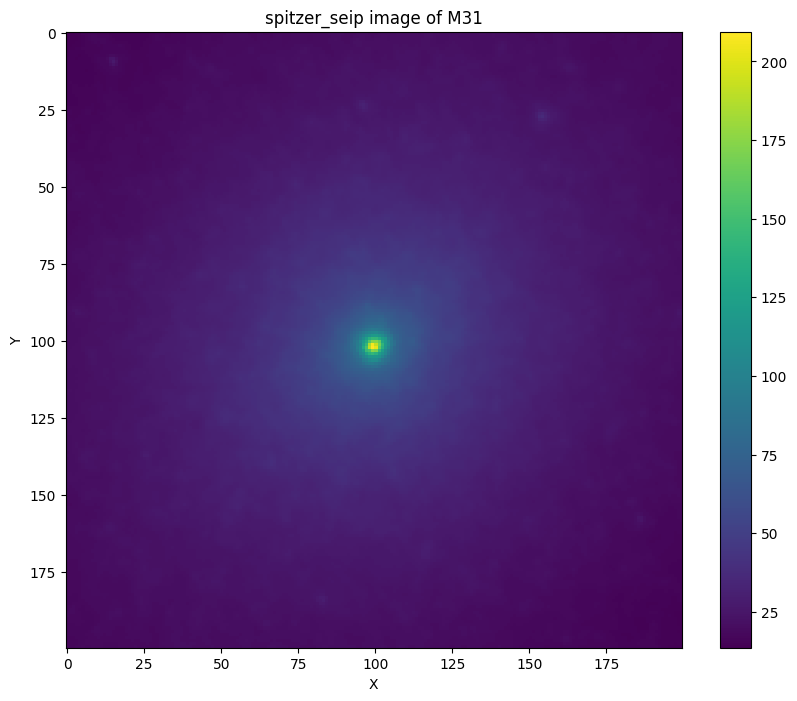

(<matplotlib.image.AxesImage at 0x78fd7b5dbfd0>,
 None)

In [51]:
# Open cutout image for one science image
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
import matplotlib.pyplot as plt

images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection=collection).to_table()
image = images[images['dataproduct_subtype'] == 'science'][0]
with fits.open(image['access_url'], use_fsspec=True) as hdul:
    cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

plt.figure(figsize=(10, 8)).add_subplot().set(title=f'{collection} image of {object_name}', xlabel='X', ylabel='Y')
plt.imshow(cutout.data, cmap='viridis'), plt.colorbar(), plt.show()

In [20]:
# How many science picture are there in the catalog for the specific object?
science_images_count = len(images[images['dataproduct_subtype'] == 'science'])
print("Number of science images:", science_images_count)

Number of science images: 32


 [astropy.io.fits.verify]

 [astropy.io.fits.verify]



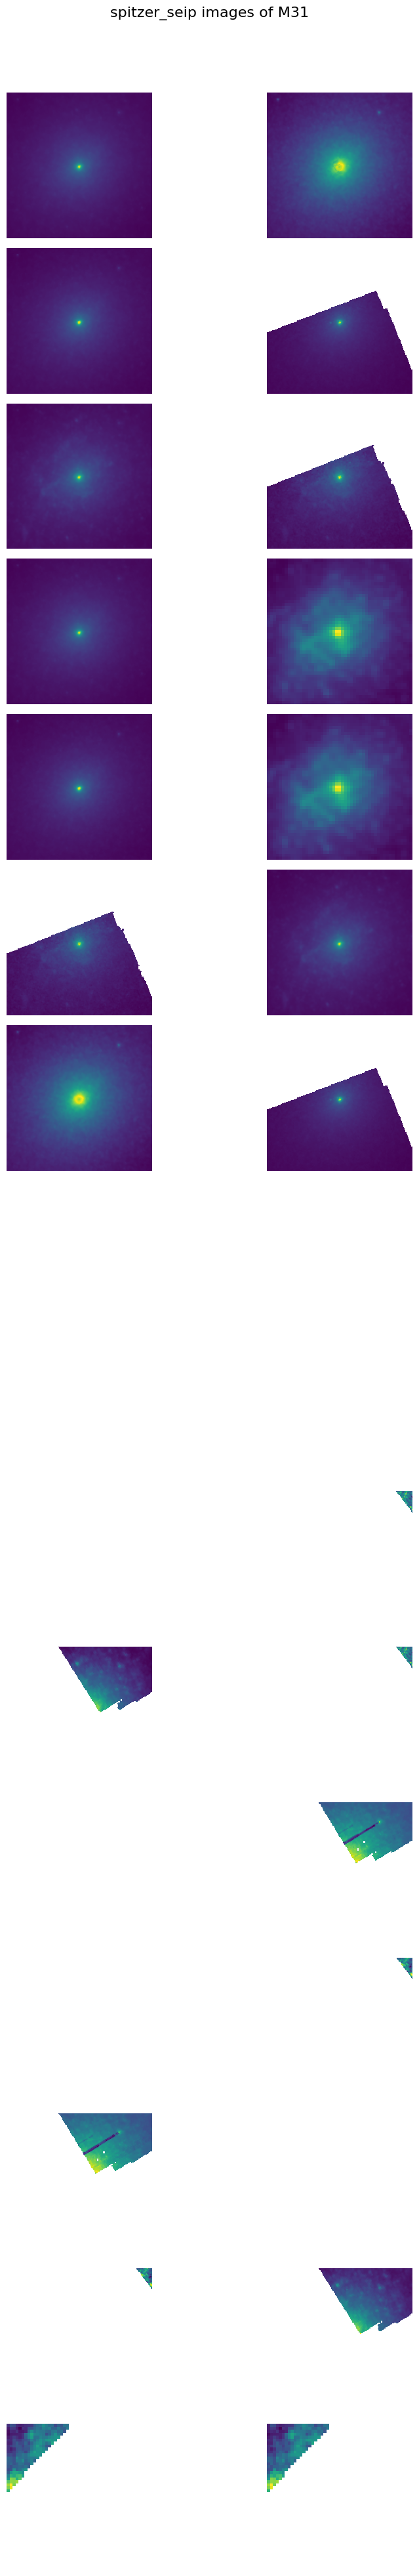

In [23]:
# Simple image access queries from IRSA for object images from telescope
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
spitzer_images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection='spitzer_seip').to_table()

# Filter for science images only
science_images = spitzer_images[spitzer_images['dataproduct_subtype'] == 'science']

# Set up the figure for a grid (2 images per row, total number of images/2 rows)

n_rows = len(science_images) // 2  # Integer division to get half the count
fig, axes = plt.subplots(n_rows, 2, figsize=(10, 2.5 * n_rows))  # Adjust figsize proportionally

# Loop through each of the science images of the images
for i in range(science_images_count):
    # Access each science image URL
    science_image = science_images[i]
    with fits.open(science_image['access_url'], use_fsspec=True) as hdul:
        cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

    # Plot the cutout in the grid
    ax = axes[i // 2, i % 2]  # Calculate row and column for 2 images per row
    ax.imshow(cutout.data, cmap='viridis')
    ax.axis('off')  # Hide axes for clarity

plt.suptitle(f'{collection} images of {object_name}', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout for the title
plt.show()



---



In [ ]:
# Query the SEIP source catalog
seip_sources = Irsa.query_region(coord, catalog='seip_science', radius=1*u.arcmin)

In [ ]:
# For catalog queries:
allwise_sources = Irsa.query_region(coord, catalog='allwise', radius=1*u.arcmin)
wise_allsky_sources = Irsa.query_region(coord, catalog='wise_allsky', radius=1*u.arcmin)

# For image queries:
allwise_images = Irsa.query_sia(pos=(coord, 1*u.arcmin), collection='wise_allwise')
wise_allsky_images = Irsa.query_sia(pos=(coord, 1*u.arcmin), collection='wise_allsky')

#### **FITS File**

In [31]:
hdul = fits.open(image['access_url'], use_fsspec=True)

In [28]:
# Print the file information
hdul.info()

Filename: <class 'fsspec.implementations.http.HTTPFile'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      77   (4554, 4576)   float32   


In [29]:
#  Access the primary HDU (Header/Data Unit) to get the data
primary_hdu = hdul[0]
data = primary_hdu.data
print(primary_hdu.header) # Display the header to learn more about the file
print(repr(hdul[0].header))  # Science data HDU header

SIMPLE  =                    T / Fits standard                                  BITPIX  =                  -32 / Bits per pixel - floating point                NAXIS   =                    2 / Number of axes                                 NAXIS1  =                 4554 / X axis length                                  NAXIS2  =                 4576 / Y axis length                                  ORIGIN  = 'Spitzer Super-Mosaic Pipeline' / Origin of these image data          CREATOR = 'Spitzer Science Center' / Creator of this FITS file                                                                                                            / TIME AND EXPOSURE INFORMATION                                                                                                                       TELESCOP= 'Spitzer '           / Name of Telescope                              INSTRUME= 'IRAC    '           / Name of Instrument                             CHNLNUM =                    3 / Instrum

In [ ]:
# Close the FITS file
hdul.close()